In [1]:
import os
import sys
import platform

print("Operating system:", platform.system())
print("Python:", sys.executable)
print("Current folder:", os.getcwd())

Operating system: Linux
Python: /usr/bin/python3
Current folder: /content


In [2]:
!pip install -q datasets==4.4.1 transformers==4.57.1 accelerate bitsandbytes qwen-vl-utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 17.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [3]:
import os

CACHE_DIR = r"C:\Users\ADMIN\Desktop\AIMS_VCR\cache"

os.environ["HF_HOME"] = CACHE_DIR
os.environ["HF_HUB_CACHE"] = os.path.join(CACHE_DIR, "hub")
os.environ["HF_DATASETS_CACHE"] = os.path.join(CACHE_DIR, "datasets")
os.environ["TRANSFORMERS_CACHE"] = os.path.join(CACHE_DIR, "transformers")

import re
import random
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image, ImageDraw, ImageFont
from datasets import load_dataset
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

from qwen_vl_utils import process_vision_info

print("Cache:", CACHE_DIR)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Cache: C:\Users\ADMIN\Desktop\AIMS_VCR\cache
CUDA available: True
GPU: Tesla T4


In [4]:
questions_ds = load_dataset(
    "Rowan/vcr",
    "questions",
    split="train"
)

print("Questions:", len(questions_ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

questions/train-00000-of-00008.parquet:   0%|          | 0.00/76.3M [00:00<?, ?B/s]

questions/train-00001-of-00008.parquet:   0%|          | 0.00/76.8M [00:00<?, ?B/s]

...

questions/test-00007-of-00008.parquet:   0%|          | 0.00/8.97M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/212923 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/26534 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25263 [00:00<?, ? examples/s]

Questions: 212923


In [5]:
image_ds = load_dataset(
    "Rowan/vcr",
    "image_examples",
    split="train"
)

print("Images:", len(image_ds))

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

image_examples/train-00000-of-00059.parq(…):   0%|          | 0.00/446M [00:00<?, ?B/s]

image_examples/train-00001-of-00059.parq(…):   0%|          | 0.00/449M [00:00<?, ?B/s]

image_examples/train-00002-of-00059.parq(…):   0%|          | 0.00/452M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/80418 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9929 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9557 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/47 [00:00<?, ?it/s]

Images: 80418


In [6]:
import os
import subprocess

print("Largest folders in /content:")
!du -h --max-depth=1 /content 2>/dev/null | sort -hr | head -20

Largest folders in /content:
60G	/content/C:\Users\ADMIN\Desktop\AIMS_VCR\cache
60G	/content
55M	/content/sample_data
148K	/content/.config


In [7]:
import shutil
import os

old_cache = r"/content/C:\Users\ADMIN\Desktop\AIMS_VCR\cache"

if os.path.exists(old_cache):
    shutil.rmtree(old_cache)
    print("Old accidental cache deleted.")
else:
    print("Cache not found.")

Old accidental cache deleted.


In [10]:
!df -h /content
!du -h --max-depth=1 /content 2>/dev/null | sort -hr

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   72G   42G  64% /
55M	/content/sample_data
55M	/content
148K	/content/.config


In [11]:
image_index = {
    img_fn: i
    for i, img_fn in enumerate(image_ds["img_fn"])
}

print("Images indexed:", len(image_index))

Images indexed: 80418


In [12]:
from torch.utils.data import Dataset

class VCRDataset(Dataset):

    def __init__(self, questions, images, image_index):
        self.questions = questions
        self.images = images
        self.image_index = image_index

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):

        q = self.questions[idx]

        image_idx = self.image_index[q["img_fn"]]
        img = self.images[image_idx]

        return {
            "image": img["image"],
            "objects": img["objects"],
            "boxes": img["boxes"],

            "question": q["question_text"],

            "answers": q["answer_choice_texts"],
            "answer_label": q["answer_label"],

            "rationales": q["rationale_choice_texts"],
            "rationale_label": q["rationale_label"],

            "img_fn": q["img_fn"],
            "img_id": q["img_id"]
        }


vcr_dataset = VCRDataset(
    questions_ds,
    image_ds,
    image_index
)

print("Dataset size:", len(vcr_dataset))

Dataset size: 212923


In [13]:
sample = vcr_dataset[0]

print("QUESTION:")
print(sample["question"])

print("\nANSWERS:")

for i, answer in enumerate(sample["answers"]):
    print(i, ":", answer)

print("\nCORRECT ANSWER:")
print(sample["answer_label"])

print("\nOBJECTS:")

for i, obj in enumerate(sample["objects"]):
    print(i, ":", obj)

print("\nBOXES:")

for i, box in enumerate(sample["boxes"]):
    print(i, ":", box)

QUESTION:
Does [person2] feel comfortable?

ANSWERS:
0 : Yes because the person sitting next to her is smiling.
1 : No she does not.
2 : Yes, she is wearing something with thin straps.
3 : Yes, she is cold.

CORRECT ANSWER:
1

OBJECTS:
0 : person
1 : person
2 : person
3 : car

BOXES:
0 : [953.9031982421875, 139.72866821289062, 1471.0701904296875, 768.2879638671875, 0.9985432624816895]
1 : [657.2943725585938, 25.674560546875, 1062.8427734375, 745.1873168945312, 0.998895525932312]
2 : [241.59446716308594, 54.851593017578125, 620.8653564453125, 700.7781982421875, 0.9988077878952026]
3 : [2.4555816650390625, 331.0960693359375, 277.36383056640625, 579.8651733398438, 0.7267032265663147]


In [14]:
def make_box_image(image, objects, boxes):

    image = image.copy()
    draw = ImageDraw.Draw(image)

    for i, box in enumerate(boxes):

        x1, y1, x2, y2 = box[:4]

        x1 = int(x1)
        y1 = int(y1)
        x2 = int(x2)
        y2 = int(y2)

        label = f"{objects[i]}{i}"

        draw.rectangle(
            [x1, y1, x2, y2],
            outline="red",
            width=4
        )

        draw.rectangle(
            [x1, max(0, y1 - 25), x1 + 100, y1],
            fill="red"
        )

        draw.text(
            (x1 + 3, max(0, y1 - 23)),
            label,
            fill="white"
        )

    return image

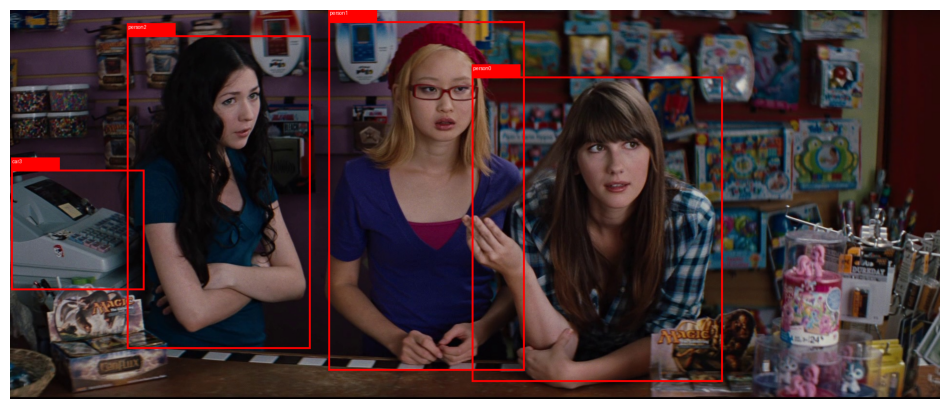

In [15]:
boxed_image = make_box_image(
    sample["image"],
    sample["objects"],
    sample["boxes"]
)

plt.figure(figsize=(12, 8))
plt.imshow(boxed_image)
plt.axis("off")
plt.show()

In [16]:
def make_crop_image(image, objects, boxes):

    crops = []

    for i, box in enumerate(boxes):

        x1, y1, x2, y2 = box[:4]

        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(image.width, int(x2))
        y2 = min(image.height, int(y2))

        if x2 <= x1 or y2 <= y1:
            continue

        crop = image.crop((x1, y1, x2, y2))

        crop.thumbnail((250, 200))

        crops.append((i, objects[i], crop))

    if len(crops) == 0:
        return image.copy()

    crop_width = 280
    crop_height = 240

    panel_width = crop_width * len(crops)
    panel_height = crop_height

    panel = Image.new(
        "RGB",
        (panel_width, panel_height),
        "white"
    )

    draw = ImageDraw.Draw(panel)

    for position, (i, obj, crop) in enumerate(crops):

        x = position * crop_width

        panel.paste(
            crop,
            (
                x + 15,
                30
            )
        )

        draw.text(
            (x + 15, 5),
            f"{obj}{i}",
            fill="black"
        )

    return panel

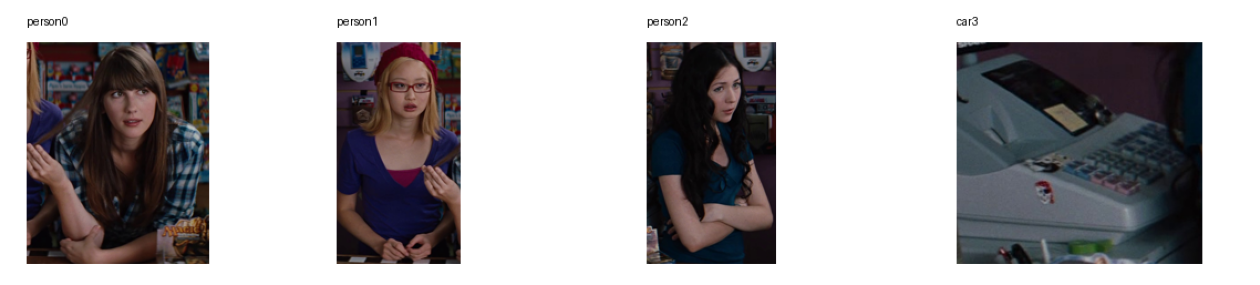

In [17]:
crop_image = make_crop_image(
    sample["image"],
    sample["objects"],
    sample["boxes"]
)

plt.figure(figsize=(16, 5))
plt.imshow(crop_image)
plt.axis("off")
plt.show()

In [19]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

processor = AutoProcessor.from_pretrained(
    model_id
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

model.eval()

print("Qwen loaded.")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Qwen loaded.


In [20]:
def ask_qwen(image, prompt):

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(
        messages
    )

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        generated_ids = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]

    output = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )[0]

    return output

In [21]:
def extract_choice(output):

    match = re.search(
        r"\b([0-3])\b",
        output
    )

    if match:
        return int(match.group(1))

    return -1

In [22]:
def make_answer_prompt(question, answers):

    prompt = f"""
You are solving a Visual Commonsense Reasoning question.

Look carefully at the image.

Question:
{question}

Answer choices:

0. {answers[0]}

1. {answers[1]}

2. {answers[2]}

3. {answers[3]}

Choose the single best answer based on the image,
the question, and commonsense reasoning.

Return ONLY the number:
0, 1, 2, or 3.
"""

    return prompt

In [23]:
NUM_SAMPLES = 100

random.seed(42)

sample_indices = random.sample(
    range(len(vcr_dataset)),
    NUM_SAMPLES
)

print("Samples:", len(sample_indices))

Samples: 100


In [24]:
def get_image_versions(sample):

    original = sample["image"]

    boxed = make_box_image(
        sample["image"],
        sample["objects"],
        sample["boxes"]
    )

    cropped = make_crop_image(
        sample["image"],
        sample["objects"],
        sample["boxes"]
    )

    return {
        "original": original,
        "boxes": boxed,
        "crops": cropped
    }

In [25]:
results = []

for count, idx in enumerate(sample_indices):

    sample = vcr_dataset[idx]

    images = get_image_versions(sample)

    question = sample["question"]
    answers = sample["answers"]
    true_answer = sample["answer_label"]

    prompt = make_answer_prompt(
        question,
        answers
    )

    row = {
        "index": idx,
        "img_fn": sample["img_fn"],
        "true_answer": true_answer
    }

    for representation, image in images.items():

        output = ask_qwen(
            image,
            prompt
        )

        prediction = extract_choice(output)

        correct = (
            prediction == true_answer
        )

        row[f"{representation}_prediction"] = prediction
        row[f"{representation}_correct"] = correct
        row[f"{representation}_output"] = output

    results.append(row)

    print(
        f"[{count + 1}/{NUM_SAMPLES}] "
        f"Original={row['original_prediction']} "
        f"Boxes={row['boxes_prediction']} "
        f"Crops={row['crops_prediction']}"
    )

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:944: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


[1/100] Original=2 Boxes=-1 Crops=2
[2/100] Original=1 Boxes=-1 Crops=1
[3/100] Original=2 Boxes=1 Crops=2
[4/100] Original=2 Boxes=-1 Crops=2
[5/100] Original=2 Boxes=2 Crops=3
[6/100] Original=3 Boxes=3 Crops=3
[7/100] Original=0 Boxes=-1 Crops=0
[8/100] Original=1 Boxes=1 Crops=1
[9/100] Original=1 Boxes=-1 Crops=0
[10/100] Original=1 Boxes=-1 Crops=1
[11/100] Original=2 Boxes=2 Crops=2
[12/100] Original=3 Boxes=-1 Crops=3
[13/100] Original=3 Boxes=-1 Crops=3
[14/100] Original=3 Boxes=-1 Crops=-1
[15/100] Original=0 Boxes=0 Crops=0
[16/100] Original=-1 Boxes=2 Crops=2
[17/100] Original=0 Boxes=-1 Crops=0
[18/100] Original=1 Boxes=1 Crops=0
[19/100] Original=2 Boxes=2 Crops=2
[20/100] Original=2 Boxes=-1 Crops=2
[21/100] Original=0 Boxes=0 Crops=0
[22/100] Original=3 Boxes=-1 Crops=3
[23/100] Original=0 Boxes=0 Crops=2
[24/100] Original=2 Boxes=-1 Crops=2
[25/100] Original=2 Boxes=1 Crops=2
[26/100] Original=1 Boxes=-1 Crops=1
[27/100] Original=0 Boxes=-1 Crops=0
[28/100] Original=2 

In [26]:
results_df = pd.DataFrame(results)

original_accuracy = results_df[
    "original_correct"
].mean()

boxes_accuracy = results_df[
    "boxes_correct"
].mean()

crops_accuracy = results_df[
    "crops_correct"
].mean()

print()
print("==============================")
print("VISUAL REPRESENTATION RESULTS")
print("==============================")

print(
    f"Original: {original_accuracy:.2%}"
)

print(
    f"Boxes:    {boxes_accuracy:.2%}"
)

print(
    f"Crops:    {crops_accuracy:.2%}"
)


VISUAL REPRESENTATION RESULTS
Original: 61.00%
Boxes:    30.00%
Crops:    56.00%
